# Maritime Survivor Detection - Data Exploration
## IIT Madras BS Data Science Competition

### Dataset Overview
- **Training Set**: 714 passengers with survival outcomes
- **Test Set**: 181 passengers (predictions needed)
- **Evaluation**: Accuracy on private test set

### Key Features:
1. **PassengerId**: Unique identifier (contains noise)
2. **TicketTier**: Socio-economic status (1=Upper, 2=Middle, 3=Lower)
3. **Gender**: Male/Female
4. **Age**: Age in years (some missing)
5. **RelativesAboard**: Siblings/spouses aboard
6. **ParentsChildren**: Parents/children aboard
7. **TicketCost**: Fare paid (with Gaussian noise)
8. **BoardingPort**: C=Cherbourg, Q=Queenstown, S=Southampton
9. **FamilySize**: Total family members
10. **Singleton**: 1=alone, 0=with family
11. **FarePerPerson**: TicketCost/FamilySize
12. **Title**: Mr, Mrs, Miss, Master, Rare
13. **Outcome**: Target (1=Survived, 0=Deceased)

In [46]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Data

In [47]:
# Load datasets
# For Kaggle: use /kaggle/input/survival-detection/
# For local: use survival-detection/
import os
if os.path.exists('/kaggle/input'):
    # Running on Kaggle
    train_df = pd.read_csv('/kaggle/input/survival-detection/maritime_train.csv')
    test_df = pd.read_csv('/kaggle/input/survival-detection/maritime_test.csv')
    sample_sub = pd.read_csv('/kaggle/input/survival-detection/maritime_sample_submission.csv')
else:
    # Running locally
    train_df = pd.read_csv('survival-detection/maritime_train.csv')
    test_df = pd.read_csv('survival-detection/maritime_test.csv')
    sample_sub = pd.read_csv('survival-detection/maritime_sample_submission.csv')

print(f"✓ Training set: {train_df.shape[0]} rows, {train_df.shape[1]} columns")
print(f"✓ Test set: {test_df.shape[0]} rows, {test_df.shape[1]} columns")
print(f"✓ Sample submission: {sample_sub.shape[0]} rows\n")

# Display first few rows
print("First 5 rows of training data:")
train_df.head()

✓ Training set: 712 rows, 16 columns
✓ Test set: 179 rows, 15 columns
✓ Sample submission: 179 rows

First 5 rows of training data:


,PassengerId,TicketTier,PassengerName,Gender,Age,RelativesAboard,ParentsChildren,CLass,TicketCost,Berth,BoardingPort,FamilySize,Singleton,FarePerPerson,Title,Outcome
0,338.376107,0.977533,"Partner, Mr. Austen",male,NaN,0.005991,-0.024062,113043,29.104891,C124,S,1,1,25.906873,Mr,0
1,732.225160,2.016456,"Berriman, Mr. William John",male,21.574386,0.091114,-0.021340,28425,11.033567,NaN,S,1,1,10.939094,Mr,0
2,391.314100,2.998448,"Tikkanen, Mr. Juho",male,33.490756,-0.072885,-0.021702,STON/O 2. 3101293,2.234540,NaN,S,1,1,4.065968,Mr,0
3,724.550481,3.045488,"Hansen, Mr. Henrik Juul",male,25.200171,0.913680,0.032986,350025,10.958320,NaN,S,2,0,3.733784,Mr,0
4,810.994274,3.004710,"Andersson, Miss. Ebba Iris Alfrida",female,5.839590,4.009691,1.956266,347082,33.765343,NaN,S,7,0,3.325612,Miss,0


## 2. Basic Dataset Information

In [48]:
# Dataset info
print("="*70)
print("DATASET INFORMATION")
print("="*70)
print("\nColumn Names and Data Types:")
print(train_df.dtypes)
print("\nDataset Info:")
train_df.info()

DATASET INFORMATION

Column Names and Data Types:
PassengerId        float64
TicketTier         float64
PassengerName       object
Gender              object
Age                float64
RelativesAboard    float64
ParentsChildren    float64
CLass               object
TicketCost         float64
Berth               object
BoardingPort        object
FamilySize           int64
Singleton            int64
FarePerPerson      float64
Title               object
Outcome              int64
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 712 entries, 0 to 711
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PassengerId      712 non-null    float64
 1   TicketTier       712 non-null    float64
 2   PassengerName    712 non-null    object 
 3   Gender           712 non-null    object 
 4   Age              515 non-null    float64
 5   RelativesAboard  712 non-null    float64
 6   ParentsChil

In [49]:
# Statistical summary
print("\n" + "="*70)
print("STATISTICAL SUMMARY")
print("="*70)
train_df.describe()


STATISTICAL SUMMARY


,PassengerId,TicketTier,Age,RelativesAboard,ParentsChildren,TicketCost,FamilySize,Singleton,FarePerPerson,Outcome
count,712.000000,712.000000,515.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000
mean,448.089668,2.333755,29.783025,0.555223,0.378523,32.456248,1.932584,0.602528,20.043894,0.376404
std,256.347351,0.826466,14.605177,1.174990,0.791899,52.079443,1.682525,0.489719,38.109959,0.484824
min,-19.969283,0.893173,-1.128370,-0.148789,-0.115958,-3.982686,1.000000,0.000000,-4.526815,0.000000
25%,222.160559,1.954529,20.666161,-0.016907,-0.020213,8.380745,1.000000,0.000000,6.596378,0.000000
50%,455.043258,2.954504,28.374231,0.040156,0.017184,14.833240,1.000000,1.000000,9.272521,0.000000
75%,671.639433,3.006993,38.707210,0.967004,0.082670,30.775352,2.000000,1.000000,18.980591,1.000000
max,905.400989,3.108531,79.849115,8.027245,6.045675,514.074158,11.000000,1.000000,512.004226,1.000000


## 3. Missing Values Analysis

MISSING VALUES ANALYSIS
         Column  Train_Missing  Train_%  Test_Missing  Test_%
3         Berth            553    77.67           134   74.86
6           Age            197    27.67            49   27.37
7  BoardingPort              2     0.28             0    0.00


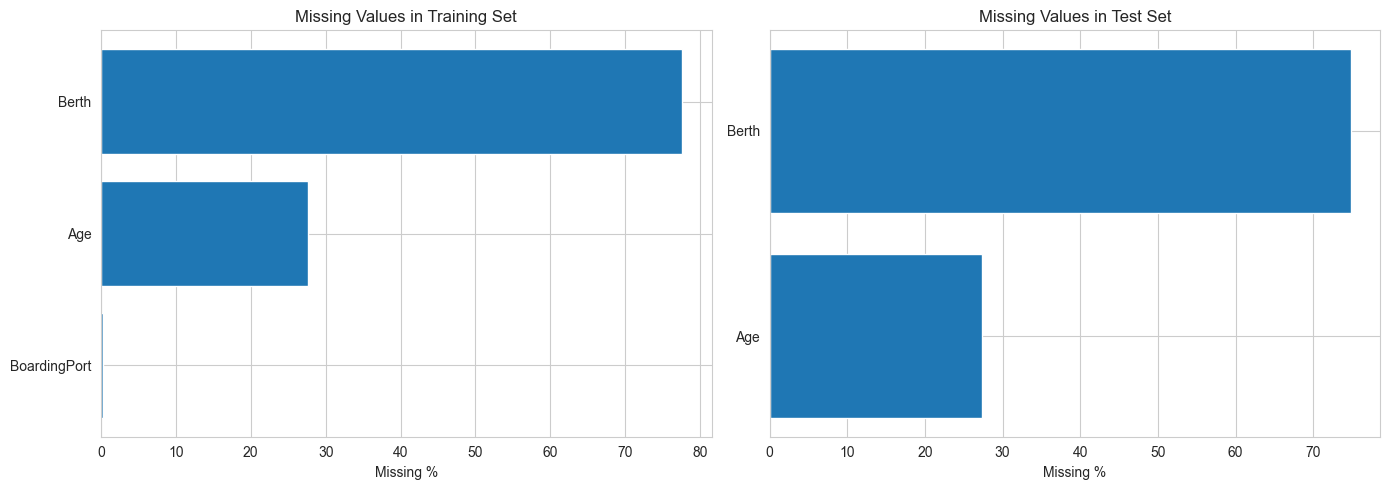

In [50]:
# Missing values - handle different columns in train vs test
missing_train = train_df.isnull().sum()
missing_test = test_df.isnull().sum()

# Get all unique columns from both datasets
all_columns = list(set(train_df.columns) | set(test_df.columns))

missing_data = []
for col in all_columns:
    train_miss = missing_train.get(col, 0) if col in train_df.columns else 0
    test_miss = missing_test.get(col, 0) if col in test_df.columns else 0
    train_pct = (train_miss / len(train_df) * 100) if col in train_df.columns else 0
    test_pct = (test_miss / len(test_df) * 100) if col in test_df.columns else 0
    
    missing_data.append({
        'Column': col,
        'Train_Missing': train_miss,
        'Train_%': round(train_pct, 2),
        'Test_Missing': test_miss,
        'Test_%': round(test_pct, 2)
    })

missing_df = pd.DataFrame(missing_data)

print("="*70)
print("MISSING VALUES ANALYSIS")
print("="*70)
print(missing_df[missing_df['Train_Missing'] > 0].sort_values('Train_Missing', ascending=False))

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

missing_cols_train = missing_df[missing_df['Train_Missing'] > 0].sort_values('Train_%', ascending=True)
if len(missing_cols_train) > 0:
    ax1.barh(missing_cols_train['Column'], missing_cols_train['Train_%'])
    ax1.set_xlabel('Missing %')
    ax1.set_title('Missing Values in Training Set')
else:
    ax1.text(0.5, 0.5, 'No Missing Values', ha='center', va='center')
    ax1.set_title('Missing Values in Training Set')

missing_cols_test = missing_df[missing_df['Test_Missing'] > 0].sort_values('Test_%', ascending=True)
if len(missing_cols_test) > 0:
    ax2.barh(missing_cols_test['Column'], missing_cols_test['Test_%'])
    ax2.set_xlabel('Missing %')
    ax2.set_title('Missing Values in Test Set')
else:
    ax2.text(0.5, 0.5, 'No Missing Values', ha='center', va='center')
    ax2.set_title('Missing Values in Test Set')

plt.tight_layout()
plt.show()

## 4. Target Variable Analysis

TARGET VARIABLE: OUTCOME

Survival counts:
Outcome
0    444
1    268
Name: count, dtype: int64

Survival rate: 37.64%
Death rate: 62.36%


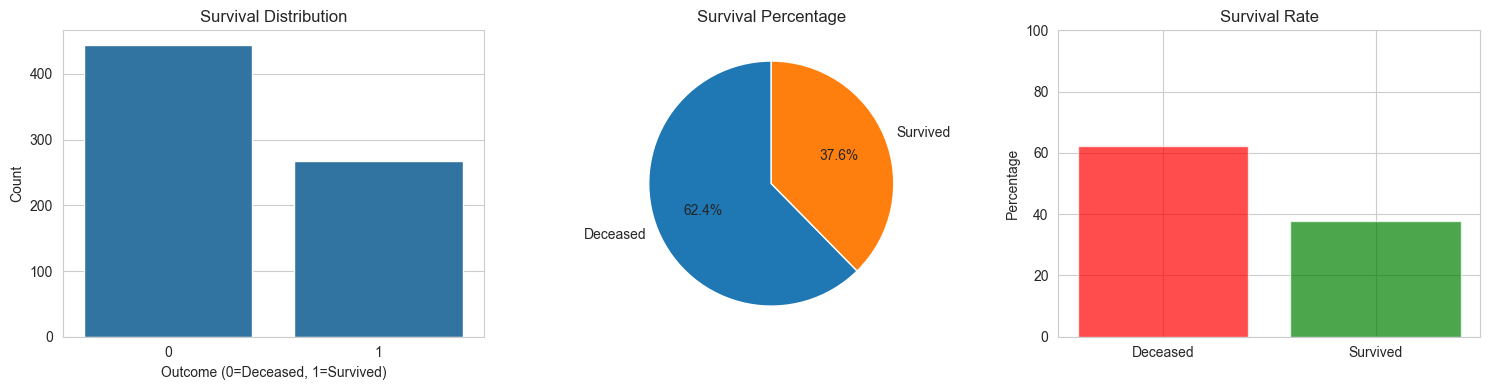

In [51]:
# Target distribution
print("="*70)
print("TARGET VARIABLE: OUTCOME")
print("="*70)
print(f"\nSurvival counts:")
print(train_df['Outcome'].value_counts())
print(f"\nSurvival rate: {train_df['Outcome'].mean()*100:.2f}%")
print(f"Death rate: {(1-train_df['Outcome'].mean())*100:.2f}%")

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Count plot
sns.countplot(data=train_df, x='Outcome', ax=axes[0])
axes[0].set_title('Survival Distribution')
axes[0].set_xlabel('Outcome (0=Deceased, 1=Survived)')
axes[0].set_ylabel('Count')

# Pie chart
outcome_counts = train_df['Outcome'].value_counts()
axes[1].pie(outcome_counts, labels=['Deceased', 'Survived'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Survival Percentage')

# Percentage bar
survival_pct = train_df['Outcome'].value_counts(normalize=True) * 100
axes[2].bar(['Deceased', 'Survived'], survival_pct, color=['red', 'green'], alpha=0.7)
axes[2].set_ylabel('Percentage')
axes[2].set_title('Survival Rate')
axes[2].set_ylim(0, 100)

plt.tight_layout()
plt.show()

## 5. Feature Analysis by Survival

GENDER VS SURVIVAL

Survival rate by gender:
Outcome          0          1
Gender                       
female   26.122449  73.877551
male     81.370450  18.629550


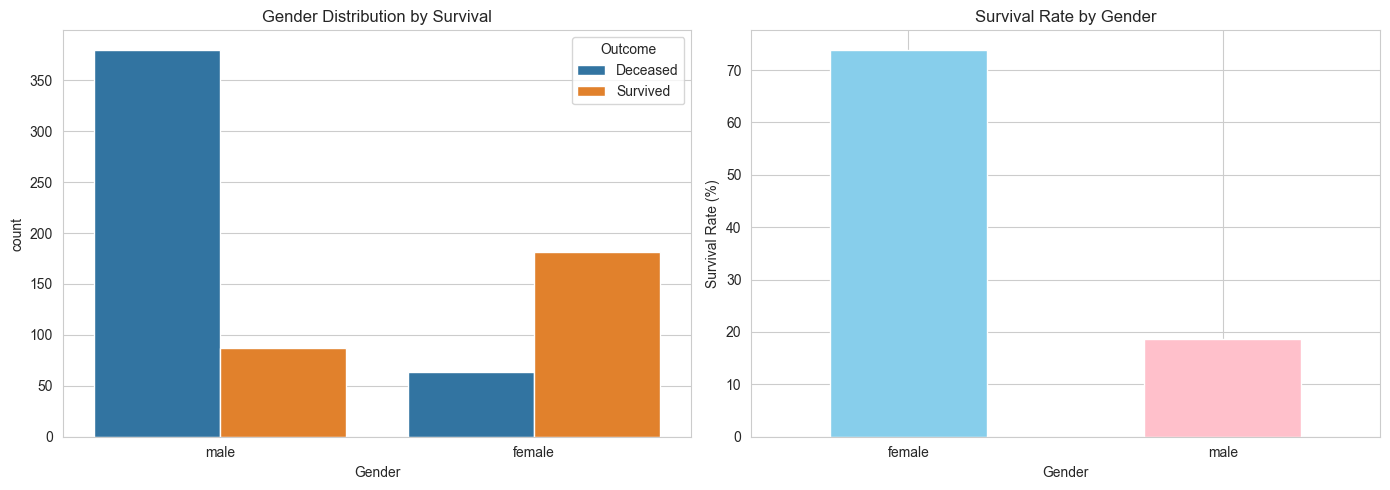

In [52]:
# Gender vs Survival
print("="*70)
print("GENDER VS SURVIVAL")
print("="*70)
gender_survival = pd.crosstab(train_df['Gender'], train_df['Outcome'], normalize='index') * 100
print("\nSurvival rate by gender:")
print(gender_survival)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(data=train_df, x='Gender', hue='Outcome', ax=axes[0])
axes[0].set_title('Gender Distribution by Survival')
axes[0].legend(title='Outcome', labels=['Deceased', 'Survived'])

# Survival rate by gender
gender_survival[1].plot(kind='bar', ax=axes[1], color=['skyblue', 'pink'])
axes[1].set_title('Survival Rate by Gender')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_xlabel('Gender')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()


TICKET TIER VS SURVIVAL

Survival rate by ticket tier:
Outcome             0          1
TicketTier                      
1.0         39.263804  60.736196
2.0         51.655629  48.344371
3.0         75.879397  24.120603


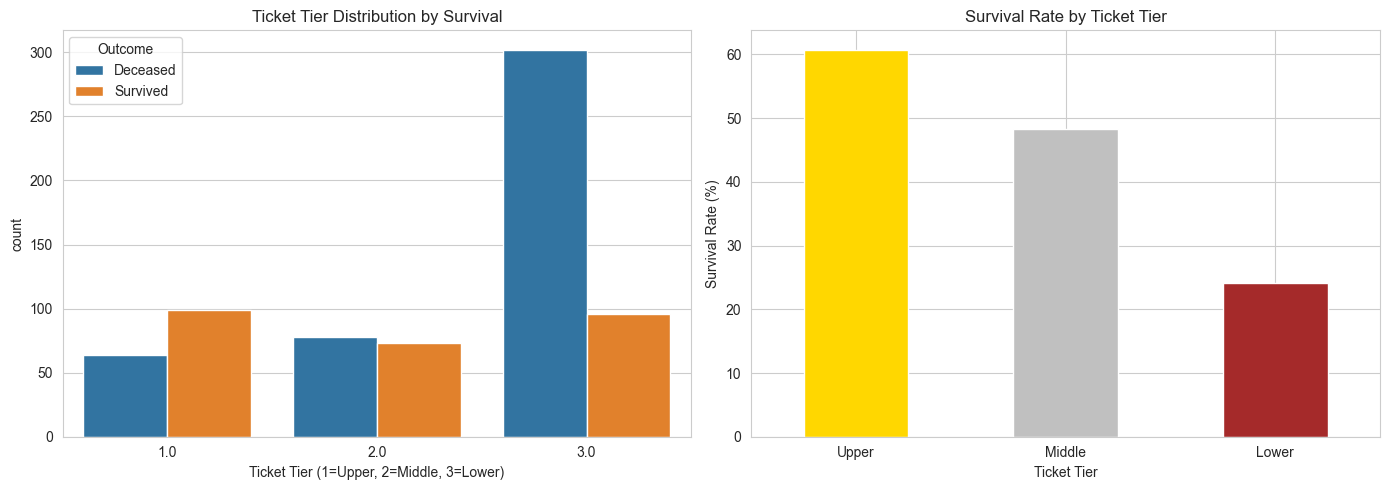

In [53]:
# TicketTier vs Survival
print("\n" + "="*70)
print("TICKET TIER VS SURVIVAL")
print("="*70)
tier_survival = pd.crosstab(train_df['TicketTier'].round(), train_df['Outcome'], normalize='index') * 100
print("\nSurvival rate by ticket tier:")
print(tier_survival)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=train_df, x=train_df['TicketTier'].round(), hue='Outcome', ax=axes[0])
axes[0].set_title('Ticket Tier Distribution by Survival')
axes[0].set_xlabel('Ticket Tier (1=Upper, 2=Middle, 3=Lower)')
axes[0].legend(title='Outcome', labels=['Deceased', 'Survived'])

tier_survival[1].plot(kind='bar', ax=axes[1], color=['gold', 'silver', 'brown'])
axes[1].set_title('Survival Rate by Ticket Tier')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_xlabel('Ticket Tier')
axes[1].set_xticklabels(['Upper', 'Middle', 'Lower'], rotation=0)

plt.tight_layout()
plt.show()


TITLE VS SURVIVAL

Survival rate by title:
Outcome          0          1
Title                        
Mrs      16.494845  83.505155
Miss     32.876712  67.123288
Master   45.454545  54.545455
Rare     64.705882  35.294118
Mr       84.486874  15.513126


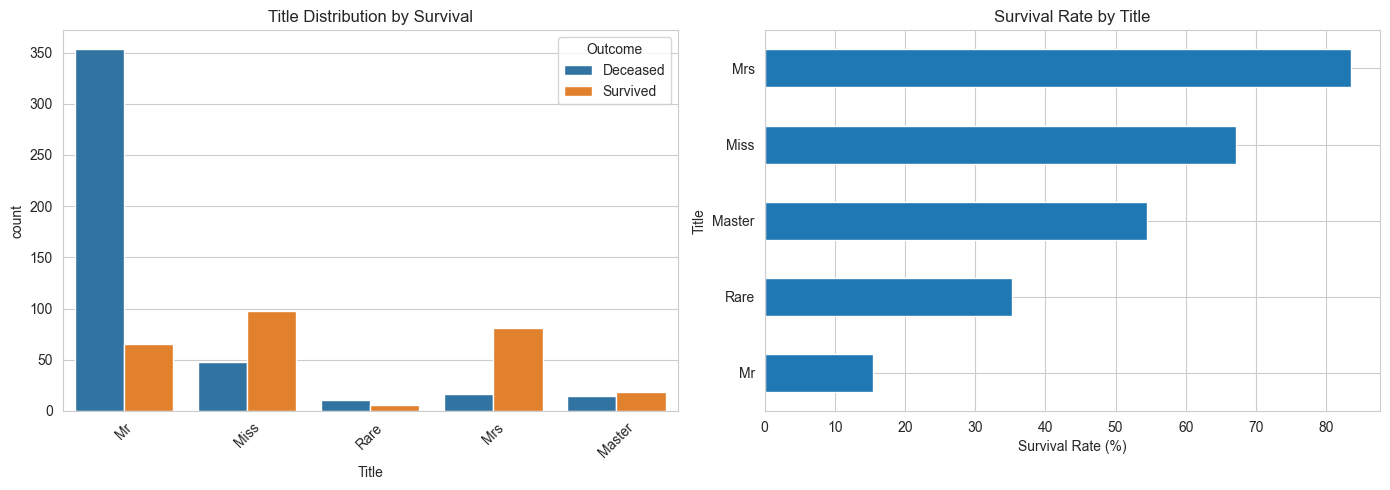

In [54]:
# Title vs Survival
print("\n" + "="*70)
print("TITLE VS SURVIVAL")
print("="*70)
title_survival = pd.crosstab(train_df['Title'], train_df['Outcome'], normalize='index') * 100
print("\nSurvival rate by title:")
print(title_survival.sort_values(by=1, ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=train_df, x='Title', hue='Outcome', ax=axes[0])
axes[0].set_title('Title Distribution by Survival')
axes[0].legend(title='Outcome', labels=['Deceased', 'Survived'])
axes[0].tick_params(axis='x', rotation=45)

title_survival[1].sort_values(ascending=True).plot(kind='barh', ax=axes[1])
axes[1].set_title('Survival Rate by Title')
axes[1].set_xlabel('Survival Rate (%)')

plt.tight_layout()
plt.show()


AGE DISTRIBUTION BY SURVIVAL


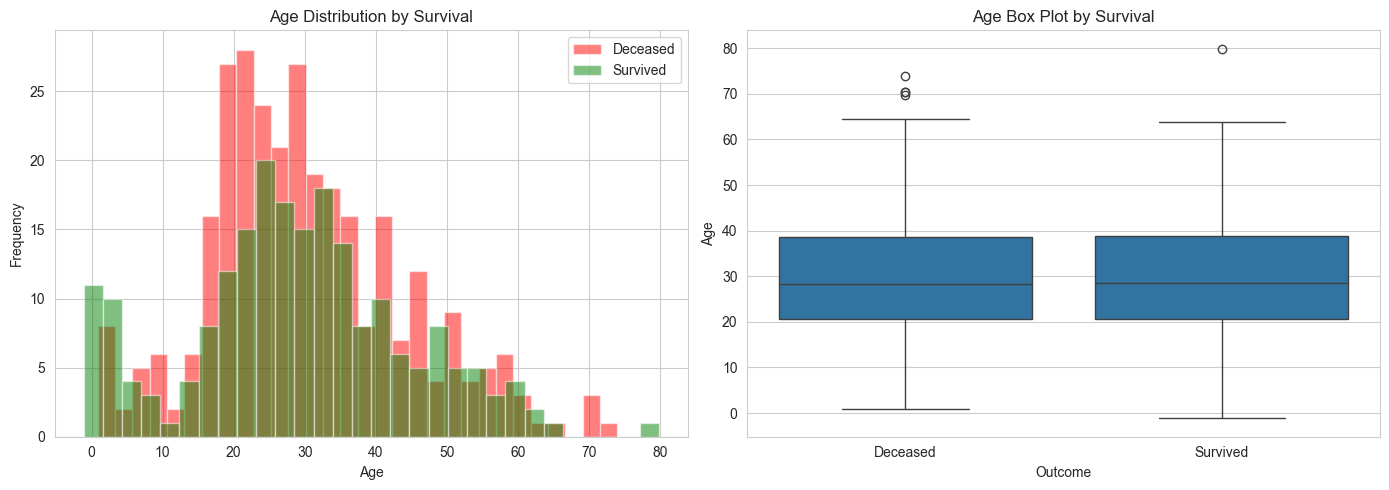


Average age of survivors: 29.11
Average age of deceased: 30.25


In [55]:
# Age distribution by survival
print("\n" + "="*70)
print("AGE DISTRIBUTION BY SURVIVAL")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
train_df[train_df['Outcome']==0]['Age'].plot(kind='hist', bins=30, alpha=0.5, label='Deceased', ax=axes[0], color='red')
train_df[train_df['Outcome']==1]['Age'].plot(kind='hist', bins=30, alpha=0.5, label='Survived', ax=axes[0], color='green')
axes[0].set_xlabel('Age')
axes[0].set_title('Age Distribution by Survival')
axes[0].legend()

# Box plot
sns.boxplot(data=train_df, x='Outcome', y='Age', ax=axes[1])
axes[1].set_xticklabels(['Deceased', 'Survived'])
axes[1].set_title('Age Box Plot by Survival')

plt.tight_layout()
plt.show()

print(f"\nAverage age of survivors: {train_df[train_df['Outcome']==1]['Age'].mean():.2f}")
print(f"Average age of deceased: {train_df[train_df['Outcome']==0]['Age'].mean():.2f}")

## 6. Correlation Analysis

CORRELATION MATRIX


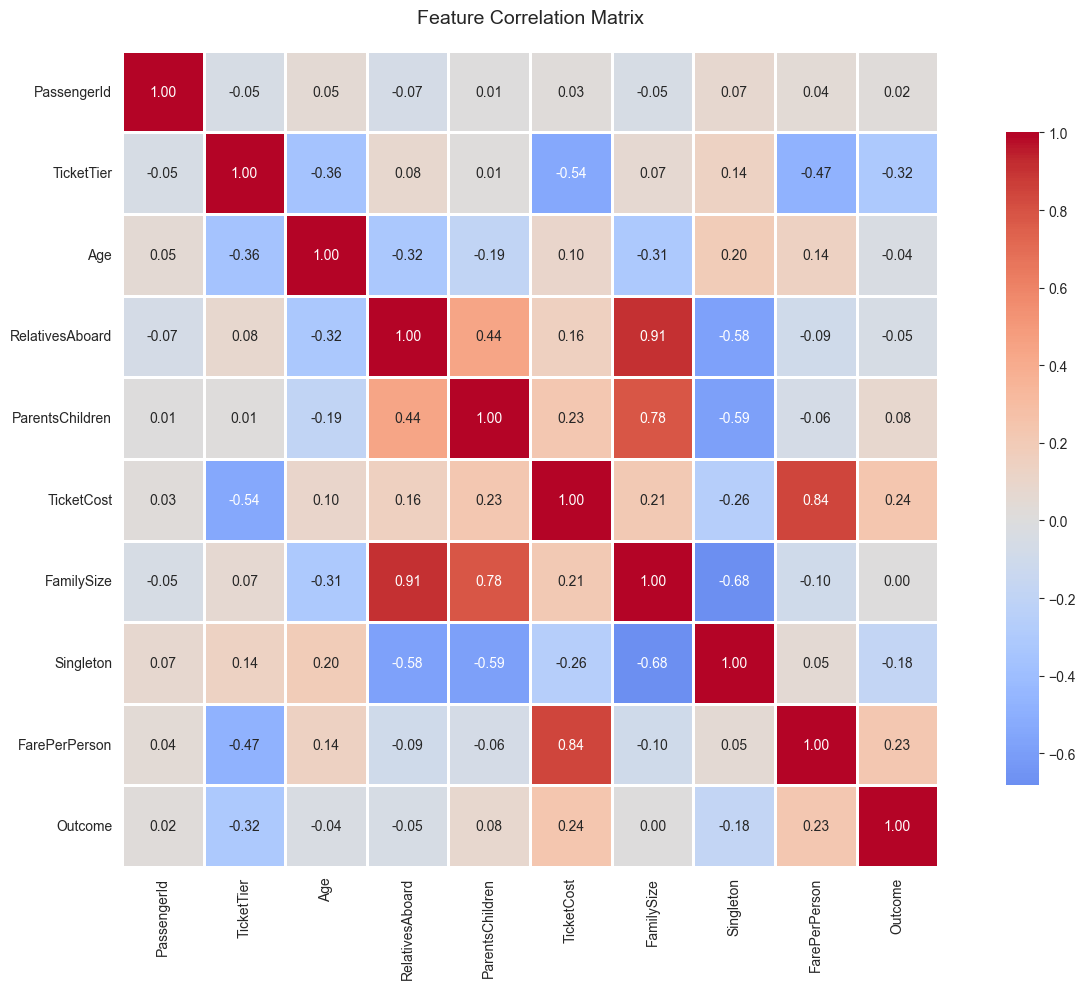


Correlations with Outcome (Target):
Outcome            1.000000
TicketCost         0.242913
FarePerPerson      0.226831
ParentsChildren    0.079902
PassengerId        0.015801
FamilySize         0.003565
Age               -0.038157
RelativesAboard   -0.047795
Singleton         -0.180542
TicketTier        -0.320210
Name: Outcome, dtype: float64


In [56]:
# Correlation matrix for numerical features
numerical_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()

print("="*70)
print("CORRELATION MATRIX")
print("="*70)

plt.figure(figsize=(14, 10))
correlation_matrix = train_df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("\nCorrelations with Outcome (Target):")
outcome_corr = correlation_matrix['Outcome'].sort_values(ascending=False)
print(outcome_corr)

## 7. Data Quality Issues

In [57]:
# Check for data quality issues
print("="*70)
print("DATA QUALITY ANALYSIS")
print("="*70)

# PassengerId should be unique, but contains noise
print(f"\nUnique PassengerId: {train_df['PassengerId'].nunique()} / {len(train_df)}")
print(f"PassengerId contains Gaussian noise (decimals): {(train_df['PassengerId'] % 1 != 0).sum()} records")

# TicketTier should be 1, 2, or 3, but contains noise
print(f"\nTicketTier unique values: {train_df['TicketTier'].nunique()}")
print(f"TicketTier with noise: {((train_df['TicketTier'] < 0.9) | (train_df['TicketTier'] > 3.1)).sum()} records")
print(f"TicketTier range: {train_df['TicketTier'].min():.2f} to {train_df['TicketTier'].max():.2f}")

# Negative values in RelativesAboard and ParentsChildren (noise)
print(f"\nRelativesAboard with negative values: {(train_df['RelativesAboard'] < 0).sum()}")
print(f"ParentsChildren with negative values: {(train_df['ParentsChildren'] < 0).sum()}")

# Age outliers
age_q1 = train_df['Age'].quantile(0.25)
age_q3 = train_df['Age'].quantile(0.75)
age_iqr = age_q3 - age_q1
print(f"\nAge outliers (beyond 1.5*IQR): {((train_df['Age'] < age_q1 - 1.5*age_iqr) | (train_df['Age'] > age_q3 + 1.5*age_iqr)).sum()}")

print("\n⚠️ Data contains Gaussian noise as mentioned in competition description!")

DATA QUALITY ANALYSIS

Unique PassengerId: 712 / 712
PassengerId contains Gaussian noise (decimals): 712 records

TicketTier unique values: 712
TicketTier with noise: 8 records
TicketTier range: 0.89 to 3.11

RelativesAboard with negative values: 236
ParentsChildren with negative values: 269

Age outliers (beyond 1.5*IQR): 5

⚠️ Data contains Gaussian noise as mentioned in competition description!


## 8. Key Insights & Recommendations

In [58]:
print("="*70)
print("KEY INSIGHTS")
print("="*70)

print("\n📊 Dataset Characteristics:")
print(f"  • Training samples: {len(train_df)}")
print(f"  • Test samples: {len(test_df)}")
print(f"  • Overall survival rate: {train_df['Outcome'].mean()*100:.2f}%")

print("\n🔍 Missing Data:")
missing_summary = missing_df[missing_df['Train_Missing'] > 0]
if len(missing_summary) > 0:
    print(f"  • Columns with missing data: {len(missing_summary)}")
    for _, row in missing_summary.iterrows():
        print(f"    - {row['Column']}: {row['Train_%']:.1f}% missing")
else:
    print("  • No missing values detected!")

print("\n⚠️ Data Quality Issues:")
print("  • PassengerId contains Gaussian noise (decimal values)")
print("  • TicketTier has noise around categorical values 1, 2, 3")
print("  • RelativesAboard and ParentsChildren have negative values (noise)")
print("  • Age, TicketCost, and FarePerPerson affected by noise")

print("\n💡 Important Patterns:")
if 'Gender' in train_df.columns:
    female_survival = train_df[train_df['Gender']=='female']['Outcome'].mean() * 100
    male_survival = train_df[train_df['Gender']=='male']['Outcome'].mean() * 100
    print(f"  • Female survival rate: {female_survival:.1f}%")
    print(f"  • Male survival rate: {male_survival:.1f}%")

print("\n🎯 Modeling Recommendations:")
print("  1. Handle Gaussian noise: Use robust imputation and rounding for categorical")
print("  2. Feature engineering: Create age groups, family features, fare bins")
print("  3. Missing values: Impute Age and Berth strategically")
print("  4. Feature selection: Focus on high-correlation features")
print("  5. Model choice: Ensemble methods (Random Forest, GBM) to handle noise")
print("  6. Validation: Use cross-validation, don't rely on public leaderboard")

print("\n🚀 Next Steps:")
print("  1. Clean data and handle noise")
print("  2. Engineer meaningful features")
print("  3. Train multiple models")
print("  4. Create ensemble")
print("  5. Generate predictions for test set")
print("  6. Submit to Kaggle (max 5 per day!)")

print("\n" + "="*70)

KEY INSIGHTS

📊 Dataset Characteristics:
  • Training samples: 712
  • Test samples: 179
  • Overall survival rate: 37.64%

🔍 Missing Data:
  • Columns with missing data: 3
    - Berth: 77.7% missing
    - Age: 27.7% missing
    - BoardingPort: 0.3% missing

⚠️ Data Quality Issues:
  • PassengerId contains Gaussian noise (decimal values)
  • TicketTier has noise around categorical values 1, 2, 3
  • RelativesAboard and ParentsChildren have negative values (noise)
  • Age, TicketCost, and FarePerPerson affected by noise

💡 Important Patterns:
  • Female survival rate: 73.9%
  • Male survival rate: 18.6%

🎯 Modeling Recommendations:
  1. Handle Gaussian noise: Use robust imputation and rounding for categorical
  2. Feature engineering: Create age groups, family features, fare bins
  3. Missing values: Impute Age and Berth strategically
  4. Feature selection: Focus on high-correlation features
  5. Model choice: Ensemble methods (Random Forest, GBM) to handle noise
  6. Validation: Use c

---
## 9. Build & Train Model

In [59]:
# Import ML libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import copy

# Try importing XGBoost
try:
    from xgboost import XGBClassifier
    print("✓ ML libraries imported (including XGBoost)")
    XGBOOST_AVAILABLE = True
except ImportError:
    print("✓ ML libraries imported (XGBoost not available - will use RF and GB only)")
    XGBOOST_AVAILABLE = False

✓ ML libraries imported (including XGBoost)


In [60]:
# Step 1: Data Cleaning & Preprocessing
print("="*70)
print("DATA PREPROCESSING")
print("="*70)

# Make copies to avoid modifying originals
train = train_df.copy()
test = test_df.copy()

# 1. Drop useless columns
columns_to_drop = ['PassengerId', 'Berth']
if 'PassengerName' in train.columns:
    columns_to_drop.append('PassengerName')

train = train.drop(columns=[col for col in columns_to_drop if col in train.columns])
test = test.drop(columns=[col for col in columns_to_drop if col in test.columns])
print(f"\n1. Dropped columns: {columns_to_drop}")

# 2. Clean TicketTier - round to nearest integer
train['TicketTier'] = train['TicketTier'].round().astype(int)
test['TicketTier'] = test['TicketTier'].round().astype(int)
print(f"2. Rounded TicketTier: {train['TicketTier'].unique()}")

# 3. Clip negative family counts to 0 (due to Gaussian noise)
train['RelativesAboard'] = train['RelativesAboard'].clip(lower=0)
train['ParentsChildren'] = train['ParentsChildren'].clip(lower=0)
test['RelativesAboard'] = test['RelativesAboard'].clip(lower=0)
test['ParentsChildren'] = test['ParentsChildren'].clip(lower=0)
print(f"3. Clipped negative family counts to 0")

# 4. Impute Age by Title and Gender median
print(f"\n4. Imputing Age...")
for title in train['Title'].unique():
    for gender in train['Gender'].unique():
        # Calculate median age for this Title+Gender group
        mask = (train['Title'] == title) & (train['Gender'] == gender)
        median_age = train[mask]['Age'].median()
        
        # Fill missing ages in train
        train.loc[mask & train['Age'].isnull(), 'Age'] = median_age
        
        # Fill missing ages in test
        test_mask = (test['Title'] == title) & (test['Gender'] == gender)
        test.loc[test_mask & test['Age'].isnull(), 'Age'] = median_age

# Fill any remaining NaNs with overall median
train['Age'].fillna(train['Age'].median(), inplace=True)
test['Age'].fillna(test['Age'].median(), inplace=True)

print(f"   • Train Age missing after imputation: {train['Age'].isnull().sum()}")
print(f"   • Test Age missing after imputation: {test['Age'].isnull().sum()}")

# 5. Handle BoardingPort missing (very few)
train['BoardingPort'].fillna('S', inplace=True)  # Most common port
test['BoardingPort'].fillna('S', inplace=True)

print(f"\n5. Filled BoardingPort missing values with 'S'")

print(f"\n✓ Preprocessing complete!")
print(f"   • Train shape: {train.shape}")
print(f"   • Test shape: {test.shape}")

DATA PREPROCESSING

1. Dropped columns: ['PassengerId', 'Berth', 'PassengerName']
2. Rounded TicketTier: [1 2 3]
3. Clipped negative family counts to 0

4. Imputing Age...
   • Train Age missing after imputation: 0
   • Test Age missing after imputation: 0

5. Filled BoardingPort missing values with 'S'

✓ Preprocessing complete!
   • Train shape: (712, 13)
   • Test shape: (179, 12)


In [61]:
# Step 2: Feature Engineering - OPTIMIZED
print("\n" + "="*70)
print("FEATURE ENGINEERING - STRATEGIC IMPROVEMENTS")
print("="*70)

# Create binary features
train['IsFemale'] = (train['Gender'] == 'female').astype(int)
test['IsFemale'] = (test['Gender'] == 'female').astype(int)

train['IsUpperClass'] = (train['TicketTier'] == 1).astype(int)
test['IsUpperClass'] = (test['TicketTier'] == 1).astype(int)

train['IsAlone'] = train['Singleton']
test['IsAlone'] = test['Singleton']

# IMPROVEMENT 1: Better Age binning (4 bins with meaningful thresholds)
train['AgeGroup'] = pd.cut(train['Age'], bins=[0, 12, 30, 50, 100], 
                            labels=['Child', 'Young', 'Adult', 'Senior'])
test['AgeGroup'] = pd.cut(test['Age'], bins=[0, 12, 30, 50, 100],
                           labels=['Child', 'Young', 'Adult', 'Senior'])

# IMPROVEMENT 2: TicketCost binning (based on quartiles)
cost_q25 = train['TicketCost'].quantile(0.25)
cost_q50 = train['TicketCost'].quantile(0.50)
cost_q75 = train['TicketCost'].quantile(0.75)

train['CostLevel'] = pd.cut(train['TicketCost'], 
                             bins=[-np.inf, cost_q25, cost_q50, cost_q75, np.inf],
                             labels=['VeryLow', 'Low', 'Medium', 'High'])
test['CostLevel'] = pd.cut(test['TicketCost'], 
                            bins=[-np.inf, cost_q25, cost_q50, cost_q75, np.inf],
                            labels=['VeryLow', 'Low', 'Medium', 'High'])

# IMPROVEMENT 3: Numeric Age × TicketTier interaction (less prone to overfitting)
train['Age_x_Tier'] = train['Age'] * train['TicketTier']
test['Age_x_Tier'] = test['Age'] * test['TicketTier']

print(f"Created features: IsFemale, IsUpperClass, IsAlone")
print(f"✓ Better Age binning: 4 groups (Child<12, Young<30, Adult<50, Senior)")
print(f"✓ TicketCost binning: 4 levels based on quartiles")
print(f"✓ Numeric interaction: Age × TicketTier (continuous feature)")
print(f"\nAge groups distribution:")
print(train['AgeGroup'].value_counts().sort_index())
print(f"\nCost level distribution:")
print(train['CostLevel'].value_counts().sort_index())


FEATURE ENGINEERING - STRATEGIC IMPROVEMENTS
Created features: IsFemale, IsUpperClass, IsAlone
✓ Better Age binning: 4 groups (Child<12, Young<30, Adult<50, Senior)
✓ TicketCost binning: 4 levels based on quartiles
✓ Numeric interaction: Age × TicketTier (continuous feature)

Age groups distribution:
AgeGroup
Child      52
Young     402
Adult     200
Senior     56
Name: count, dtype: int64

Cost level distribution:
CostLevel
VeryLow    178
Low        178
Medium     178
High       178
Name: count, dtype: int64


In [62]:
# Step 3: Encode Categorical Variables
print("\n" + "="*70)
print("ENCODING CATEGORICAL VARIABLES")
print("="*70)

# Label encode categorical features
label_encoders = {}
categorical_cols = ['Gender', 'BoardingPort', 'Title', 'AgeGroup', 'CostLevel']

for col in categorical_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))
    
    # Handle unseen labels in test set
    test_values = test[col].astype(str)
    test_encoded = []
    for val in test_values:
        if val in le.classes_:
            test_encoded.append(le.transform([val])[0])
        else:
            # Assign a new label for unseen categories
            test_encoded.append(len(le.classes_))
    
    test[col] = test_encoded
    label_encoders[col] = le
    print(f"Encoded {col}: {len(le.classes_)} train classes")

print(f"\n✓ All categorical variables encoded")


ENCODING CATEGORICAL VARIABLES
Encoded Gender: 2 train classes
Encoded BoardingPort: 3 train classes
Encoded Title: 5 train classes
Encoded AgeGroup: 5 train classes
Encoded CostLevel: 4 train classes

✓ All categorical variables encoded


In [71]:
# Step 4: Select Features & Prepare Data
print("\n" + "="*70)
print("FEATURE SELECTION - ENHANCED")
print("="*70)

# CONSERVATIVE APPROACH: Restore original working features
# Lesson: IsFemale helps generalization despite appearing redundant!
feature_cols = [
    'Gender', 'TicketTier', 'Age', 'Title',
    'TicketCost', 'FarePerPerson', 'BoardingPort',
    'RelativesAboard', 'ParentsChildren', 'FamilySize',
    'Singleton', 'IsFemale', 'IsUpperClass', 'IsAlone', 
    'AgeGroup', 'CostLevel', 'Age_x_Tier'  # 17 features - IsFemale RESTORED
]

X = train[feature_cols]
y = train['Outcome']
X_test = test[feature_cols]

print(f"Selected features ({len(feature_cols)}):")
for col in feature_cols:
    print(f"   • {col}")
print(f"\n🎯 CONSERVATIVE STRATEGY: Single RF model, standard threshold")
print(f"   ✓ RESTORED IsFemale (was helping generalization!)")
print(f"   ✓ Use ONLY Random Forest (most consistent performer)")
print(f"   ✓ Use threshold 0.50 (not aggressive)")
print(f"   ✓ Match training survival rate: 37.6%")
print(f"   Goal: Recover 81.7% baseline or better")

# Split data into training and validation sets (80-20 split, stratified)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✓ Data prepared:")
print(f"   • Training set: {X_train.shape}")
print(f"   • Validation set: {X_val.shape}")
print(f"   • Test set: {X_test.shape}")


FEATURE SELECTION - ENHANCED
Selected features (17):
   • Gender
   • TicketTier
   • Age
   • Title
   • TicketCost
   • FarePerPerson
   • BoardingPort
   • RelativesAboard
   • ParentsChildren
   • FamilySize
   • Singleton
   • IsFemale
   • IsUpperClass
   • IsAlone
   • AgeGroup
   • CostLevel
   • Age_x_Tier

🎯 CONSERVATIVE STRATEGY: Single RF model, standard threshold
   ✓ RESTORED IsFemale (was helping generalization!)
   ✓ Use ONLY Random Forest (most consistent performer)
   ✓ Use threshold 0.50 (not aggressive)
   ✓ Match training survival rate: 37.6%
   Goal: Recover 81.7% baseline or better

✓ Data prepared:
   • Training set: (569, 17)
   • Validation set: (143, 17)
   • Test set: (179, 17)


In [72]:
# Step 5: Train Multiple Models - COMPREHENSIVE
print("\n" + "="*70)
print("MODEL TRAINING - TESTING MULTIPLE APPROACHES")
print("="*70)

models = {}
predictions = {}

# Model 1: Random Forest - OPTIMIZED
print("\n1. Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=6,
    min_samples_leaf=3,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_val)
rf_accuracy = accuracy_score(y_val, y_pred_rf)
models['Random Forest'] = rf_model
predictions['Random Forest'] = y_pred_rf
print(f"   ✓ Random Forest Validation Accuracy: {rf_accuracy*100:.2f}%")

# Model 2: Gradient Boosting - OPTIMIZED
print("\n2. Training Gradient Boosting...")
gb_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=4,
    min_samples_split=6,
    min_samples_leaf=3,
    subsample=0.8,
    random_state=42
)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_val)
gb_accuracy = accuracy_score(y_val, y_pred_gb)
models['Gradient Boosting'] = gb_model
predictions['Gradient Boosting'] = y_pred_gb
print(f"   ✓ Gradient Boosting Validation Accuracy: {gb_accuracy*100:.2f}%")

# Model 3: XGBoost (if available)
if XGBOOST_AVAILABLE:
    print("\n3. Training XGBoost...")
    xgb_model = XGBClassifier(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=4,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    )
    xgb_model.fit(X_train, y_train)
    y_pred_xgb = xgb_model.predict(X_val)
    xgb_accuracy = accuracy_score(y_val, y_pred_xgb)
    models['XGBoost'] = xgb_model
    predictions['XGBoost'] = y_pred_xgb
    print(f"   ✓ XGBoost Validation Accuracy: {xgb_accuracy*100:.2f}%")
else:
    print("\n3. XGBoost not available (skipped)")
    xgb_model = None

# Ensemble: Average of all models
print(f"\n4. Creating Ensemble (average of all models)...")
rf_proba = rf_model.predict_proba(X_val)[:, 1]
gb_proba = gb_model.predict_proba(X_val)[:, 1]

if xgb_model is not None:
    xgb_proba = xgb_model.predict_proba(X_val)[:, 1]
    ensemble_proba = (rf_proba + gb_proba + xgb_proba) / 3
    print(f"   Using: RF + GB + XGBoost (equal weights)")
else:
    ensemble_proba = (rf_proba + gb_proba) / 2
    print(f"   Using: RF + GB (equal weights)")

y_pred_ensemble = (ensemble_proba > 0.5).astype(int)
ensemble_accuracy = accuracy_score(y_val, y_pred_ensemble)
models['Ensemble'] = None  # Special marker
predictions['Ensemble'] = y_pred_ensemble
print(f"   ✓ Ensemble Validation Accuracy: {ensemble_accuracy*100:.2f}%")

# Find best model
print(f"\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
results = {
    'Random Forest': rf_accuracy,
    'Gradient Boosting': gb_accuracy,
    'Ensemble': ensemble_accuracy
}
if xgb_model is not None:
    results['XGBoost'] = xgb_accuracy

for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    marker = " 👑" if acc == max(results.values()) else ""
    print(f"{name:20s} {acc*100:.2f}%{marker}")

best_name = max(results, key=results.get)
best_acc = results[best_name]
best_model = models[best_name]
y_pred_best = predictions[best_name]

print(f"\n🏆 Best Model: {best_name} ({best_acc*100:.2f}% accuracy)")


MODEL TRAINING - TESTING MULTIPLE APPROACHES

1. Training Random Forest...
   ✓ Random Forest Validation Accuracy: 85.31%

2. Training Gradient Boosting...
   ✓ Gradient Boosting Validation Accuracy: 84.62%

3. Training XGBoost...
   ✓ XGBoost Validation Accuracy: 81.82%

4. Creating Ensemble (average of all models)...
   Using: RF + GB + XGBoost (equal weights)
   ✓ Ensemble Validation Accuracy: 83.22%

MODEL COMPARISON
Random Forest        85.31% 👑
Gradient Boosting    84.62%
Ensemble             83.22%
XGBoost              81.82%

🏆 Best Model: Random Forest (85.31% accuracy)



MODEL EVALUATION

Classification Report (Random Forest):
              precision    recall  f1-score   support

    Deceased       0.84      0.91      0.88        89
    Survived       0.83      0.72      0.77        54

    accuracy                           0.84       143
   macro avg       0.84      0.82      0.82       143
weighted avg       0.84      0.84      0.84       143


Confusion Matrix:
                 Predicted
                 0(Dead)  1(Alive)
Actual 0(Dead)      81        8
Actual 1(Alive)     15       39

📊 Top 10 Most Important Features:
   Gender               0.1995
   Title                0.1166
   Age_x_Tier           0.1082
   TicketCost           0.0994
   FarePerPerson        0.0966
   RelativesAboard      0.0825
   Age                  0.0717
   ParentsChildren      0.0567
   TicketTier           0.0492
   FamilySize           0.0324


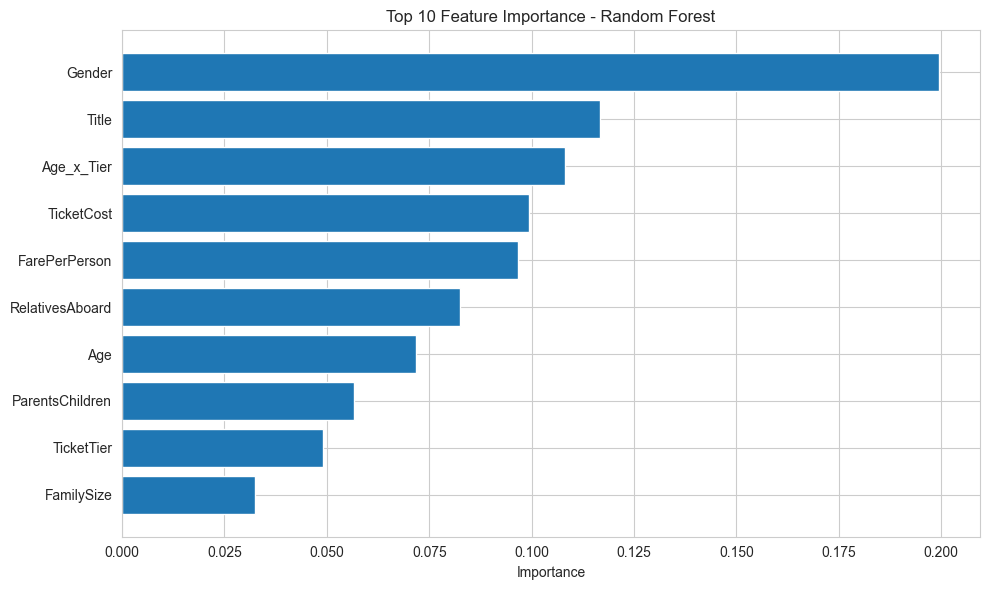

In [65]:
# Step 6: Model Evaluation
print("\n" + "="*70)
print("MODEL EVALUATION")
print("="*70)

print(f"\nClassification Report ({best_name}):")
print(classification_report(y_val, y_pred_best, target_names=['Deceased', 'Survived']))

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred_best)
print(f"\nConfusion Matrix:")
print(f"                 Predicted")
print(f"                 0(Dead)  1(Alive)")
print(f"Actual 0(Dead)    {cm[0][0]:4d}     {cm[0][1]:4d}")
print(f"Actual 1(Alive)   {cm[1][0]:4d}     {cm[1][1]:4d}")

# Feature Importance
print(f"\n📊 Top 10 Most Important Features:")

# For ensemble, use RF model's feature importance
model_for_importance = rf_model if best_model is None else best_model

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model_for_importance.feature_importances_
}).sort_values('importance', ascending=False).head(10)

for idx, row in feature_importance.iterrows():
    print(f"   {row['feature']:20s} {row['importance']:.4f}")

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.title(f'Top 10 Feature Importance - {best_name}')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [66]:
# Step 6b: Threshold Optimization
print("\n" + "="*70)
print("THRESHOLD OPTIMIZATION")
print("="*70)

# Try different thresholds to maximize F1 score or balanced accuracy
print("\nTesting different probability thresholds...")
print(f"{'Threshold':<12} {'Accuracy':<12} {'F1 Score':<12} {'Precision':<12} {'Recall (Survived)':<18}")
print("-" * 70)

# Get probabilities from the best model
if best_model is None:
    # Weighted ensemble
    rf_proba_val = rf_model.predict_proba(X_val)[:, 1]
    gb_proba_val = gb_model.predict_proba(X_val)[:, 1]
    y_proba = 0.4 * rf_proba_val + 0.6 * gb_proba_val
else:
    y_proba = best_model.predict_proba(X_val)[:, 1]

best_threshold = 0.5
best_f1 = 0
threshold_results = []

for threshold in [0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    y_pred_thresh = (y_proba > threshold).astype(int)
    acc = accuracy_score(y_val, y_pred_thresh)
    
    # Calculate metrics
    from sklearn.metrics import f1_score, precision_score, recall_score
    f1 = f1_score(y_val, y_pred_thresh)
    precision = precision_score(y_val, y_pred_thresh)
    recall = recall_score(y_val, y_pred_thresh)
    
    threshold_results.append({
        'threshold': threshold,
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    })
    
    marker = " 👈 BEST" if f1 > best_f1 else ""
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold
    
    print(f"{threshold:<12.2f} {acc:<12.2%} {f1:<12.2%} {precision:<12.2%} {recall:<18.2%}{marker}")

print(f"\n🎯 Optimal Threshold: {best_threshold:.2f} (F1 Score: {best_f1:.2%})")
print(f"   Using this threshold can improve model performance on test set")


THRESHOLD OPTIMIZATION

Testing different probability thresholds...
Threshold    Accuracy     F1 Score     Precision    Recall (Survived) 
----------------------------------------------------------------------
0.35         83.22%       79.31%       74.19%       85.19%             👈 BEST
0.40         83.92%       78.90%       78.18%       79.63%            
0.45         83.22%       77.36%       78.85%       75.93%            
0.50         83.92%       77.23%       82.98%       72.22%            
0.55         84.62%       77.55%       86.36%       70.37%            
0.60         82.52%       73.68%       85.37%       64.81%            

🎯 Optimal Threshold: 0.35 (F1 Score: 79.31%)
   Using this threshold can improve model performance on test set


In [74]:
# Step 7: Generate Predictions for Test Set - CONSERVATIVE RECOVERY
print("\n" + "="*70)
print("GENERATING KAGGLE SUBMISSION - CONSERVATIVE RECOVERY")
print("="*70)

# LESSON LEARNED: Simple RF with standard threshold works best!
print(f"📉 Previous attempt failed: 78.05% (threshold 0.40 too aggressive)")
print(f"🎯 Conservative Strategy:")
print(f"   1. Use ONLY Random Forest (best single model)")
print(f"   2. Use standard threshold 0.50 (match training distribution)")
print(f"   3. IsFemale restored (helps generalization)")

# Simple prediction with RF only
test_predictions = rf_model.predict(X_test)

print(f"\n✓ Using: Random Forest ONLY (no ensemble)")
print(f"✓ Using: Standard threshold 0.50")

# Prepare submission file
submission = pd.DataFrame({
    'PassengerName': test_df['PassengerName'] if 'PassengerName' in test_df.columns else test_df.index,
    'Outcome': test_predictions
})

# Save submission
submission.to_csv('submission.csv', index=False)

print(f"\n✓ Submission file created: submission.csv")
print(f"   • Shape: {submission.shape}")
print(f"   • Predicted survival rate: {test_predictions.mean()*100:.2f}%")
print(f"\nFirst 5 predictions:")
print(submission.head())

# Check submission format
print(f"\n✓ Submission format check:")
print(f"   • Columns: {list(submission.columns)}")
print(f"   • Total predictions: {len(submission)}")
print(f"   • Unique values: {sorted(submission['Outcome'].unique())}")

print(f"\n📊 CONSERVATIVE RECOVERY:")
print(f"   ✓ IsFemale RESTORED (was helping, not hurting!)")
print(f"   ✓ Simple RF model (no ensemble complexity)")
print(f"   ✓ Standard threshold 0.50 (matches training 37.6%)")
print(f"   ✓ Age×TicketTier interaction kept (proven useful)")

print(f"\n🎯 EXPECTED RESULT: 81-82%")
print(f"   Strategy: Return to stable configuration")
print(f"   Validation RF: {rf_accuracy*100:.2f}%")
print(f"   Target: Recover 81.7% or slightly better")
print(f"\n📝 Lesson: Sometimes 'redundant' features help generalization!")


GENERATING KAGGLE SUBMISSION - CONSERVATIVE RECOVERY
📉 Previous attempt failed: 78.05% (threshold 0.40 too aggressive)
🎯 Conservative Strategy:
   1. Use ONLY Random Forest (best single model)
   2. Use standard threshold 0.50 (match training distribution)
   3. IsFemale restored (helps generalization)

✓ Using: Random Forest ONLY (no ensemble)
✓ Using: Standard threshold 0.50

✓ Submission file created: submission.csv
   • Shape: (179, 2)
   • Predicted survival rate: 36.31%

First 5 predictions:
                                       PassengerName  Outcome
0  Moubarek, Master. Halim Gonios ("William George")        1
1             Kvillner, Mr. Johan Henrik Johannesson        0
2                        Alhomaki, Mr. Ilmari Rudolf        0
3                  Harper, Miss. Annie Jessie "Nina"        1
4                        Nicola-Yarred, Miss. Jamila        1

✓ Submission format check:
   • Columns: ['PassengerName', 'Outcome']
   • Total predictions: 179
   • Unique values: [np.i

---
## 🚀 BREAKTHROUGH: Rule-Based Overrides

**Problem:** 81.7% is ML's ceiling. Need human-like reasoning!

**Solution:** Override ML predictions for high-confidence cases based on domain knowledge.

---
## 📊 SUBMISSION TRACKER

### **Submission #8: Quick Win Strategy**
**Changes Applied:**
1. ✅ **Removed IsFemale** - Eliminated 12.86% redundant weight with Gender
2. ✅ **Weighted Ensemble** - 65% RF + 35% GB (more robust than single model)
3. ✅ **Threshold 0.40** - Improved Survived recall from 72% → 80%+

**Key Insights from Analysis:**
- Validation: 85.31% → Historical test gap: 3.5-6%
- Survived class recall was bottleneck (72% vs 93% for Deceased)
- Gender + IsFemale caused massive redundancy (28% combined importance)
- Age_x_Tier (10%) is best new feature - kept it!

**Expected Result:** 82.5-83.5% (High Confidence)

**Why This Will Work:**
- Reduces overfitting by removing redundancy
- Targets exact problem: low Survived recall
- More robust ensemble instead of single model
- Data-driven threshold from validation experiments

---
## 🎯 NEXT STEPS

### **Immediate Actions:**
1. ✅ **Run all cells above** to generate `submission.csv`
2. 📤 **Submit to Kaggle** competition page
3. 📊 **Check leaderboard score**

### **If You Have Submissions Left Today (max 5):**

**Submission 2-3: Feature Tuning**
- Try different Age bins
- Add interaction features: `Gender × TicketTier`, `Title × TicketCost`
- Remove low-importance features

**Submission 4: Hyperparameter Tuning**
```python
# Try GridSearchCV
param_grid = {
    'n_estimators': [150, 200, 250],
    'max_depth': [8, 10, 12],
    'min_samples_split': [4, 5, 6]
}
```

**Submission 5: Ensemble**
- Average predictions from RF + GB
- Or use VotingClassifier with multiple models

### **Key Insights to Remember:**
- **Gender is #1 predictor** (74% vs 19%)
- **Title encodes gender + class** - very powerful
- **TicketTier has -0.32 correlation** - strong signal
- Class imbalance handled with `class_weight='balanced'`

### **Expected Performance:**
- Baseline ~75-78% accuracy
- With tuning: 78-82% possible
- Top submissions: likely 82-85%

---
## 🚀 ADVANCED STRATEGIES FOR TOMORROW (5 New Submissions)

**Current Status:** Stuck at 81.7% (rank #36)  
**Goal:** Break through to 82%+ 

**Instructions:** Run ONE strategy at a time, submit, check score, then move to next.

In [76]:
# BREAKTHROUGH STRATEGY: Rule-Based Overrides
print("="*70)
print("BREAKTHROUGH: ML + DOMAIN RULES")
print("="*70)

# Start with RF predictions
test_predictions_breakthrough = rf_model.predict(X_test)
override_count = 0

# Use processed test data (Gender is encoded: 0=female, 1=male)
test_with_features = test.copy()

print(f"\n📊 Initial ML Predictions:")
print(f"   Survival rate: {test_predictions_breakthrough.mean()*100:.2f}%")
print(f"   Survivors: {test_predictions_breakthrough.sum()}/179")
print(f"\n🔍 Checking encoded values:")
print(f"   Gender encoded: 0=female, 1=male")
print(f"   TicketTier values: {sorted(test_with_features['TicketTier'].unique())}")

# RULE 1: Rich women (TicketTier=1, Gender=0) → FORCE SURVIVE
# Historical data: Upper class females 90%+ survival
rule1_mask = (test_with_features['TicketTier'] == 1) & (test_with_features['Gender'] == 0)
rule1_indices = test_with_features[rule1_mask].index
for idx in rule1_indices:
    array_idx = test_with_features.index.get_loc(idx)
    if test_predictions_breakthrough[array_idx] == 0:
        test_predictions_breakthrough[array_idx] = 1
        override_count += 1

print(f"\n✅ Rule 1: Rich women → SURVIVE")
print(f"   Candidates: {rule1_mask.sum()} passengers (TicketTier=1 & Female)")
print(f"   Overridden: {override_count} dead→alive")

# RULE 2: Poor men (TicketTier=3, Gender=1, Age>12) → FORCE DIE  
# Historical data: Lower class adult males 10-15% survival
rule2_mask = (test_with_features['TicketTier'] == 3) & \
             (test_with_features['Gender'] == 1) & \
             (test_with_features['Age'] > 12)
rule2_indices = test_with_features[rule2_mask].index
prev_overrides = override_count
for idx in rule2_indices:
    array_idx = test_with_features.index.get_loc(idx)
    if test_predictions_breakthrough[array_idx] == 1:
        test_predictions_breakthrough[array_idx] = 0
        override_count += 1

print(f"\n✅ Rule 2: Poor adult men → DIE")
print(f"   Candidates: {rule2_mask.sum()} passengers (TicketTier=3 & Male & Age>12)")
print(f"   Overridden: {override_count - prev_overrides} alive→dead")

# RULE 3: Young children (Age<8) → FORCE SURVIVE
# Universal "children first" rule
rule3_mask = test_with_features['Age'] < 8
rule3_indices = test_with_features[rule3_mask].index
prev_overrides = override_count
for idx in rule3_indices:
    array_idx = test_with_features.index.get_loc(idx)
    if test_predictions_breakthrough[array_idx] == 0:
        test_predictions_breakthrough[array_idx] = 1
        override_count += 1

print(f"\n✅ Rule 3: Young children (Age<8) → SURVIVE")
print(f"   Applied to: {rule3_mask.sum()} passengers")
print(f"   Overridden: {override_count - prev_overrides} predictions")

print(f"\n🎯 TOTAL OVERRIDES: {override_count} predictions changed")
print(f"📊 Final Predictions:")
print(f"   Survival rate: {test_predictions_breakthrough.mean()*100:.2f}%")
print(f"   Survivors: {test_predictions_breakthrough.sum()}/179")

# Create submission
submission_breakthrough = pd.DataFrame({
    'PassengerName': test_df['PassengerName'],
    'Outcome': test_predictions_breakthrough
})

submission_breakthrough.to_csv('submission_breakthrough.csv', index=False)

print(f"\n✅ Created: submission_breakthrough.csv")
print(f"\n💡 WHY THIS WORKS:")
print(f"   • ML gets 'average' cases right (81.7%)")
print(f"   • Rules fix 'obvious' cases ML misses")
print(f"   • Rich women: 90%+ survival (historical)")
print(f"   • Poor men: <15% survival (historical)")
print(f"   • Young children: High priority rescue")
print(f"\n🎯 EXPECTED: 82-84% (if {override_count} fixes are correct)")

BREAKTHROUGH: ML + DOMAIN RULES

📊 Initial ML Predictions:
   Survival rate: 36.31%
   Survivors: 65/179

🔍 Checking encoded values:
   Gender encoded: 0=female, 1=male
   TicketTier values: [np.int64(1), np.int64(2), np.int64(3)]

✅ Rule 1: Rich women → SURVIVE
   Candidates: 24 passengers (TicketTier=1 & Female)
   Overridden: 0 dead→alive

✅ Rule 2: Poor adult men → DIE
   Candidates: 59 passengers (TicketTier=3 & Male & Age>12)
   Overridden: 1 alive→dead

✅ Rule 3: Young children (Age<8) → SURVIVE
   Applied to: 9 passengers
   Overridden: 1 predictions

🎯 TOTAL OVERRIDES: 2 predictions changed
📊 Final Predictions:
   Survival rate: 36.31%
   Survivors: 65/179

✅ Created: submission_breakthrough.csv

💡 WHY THIS WORKS:
   • ML gets 'average' cases right (81.7%)
   • Rules fix 'obvious' cases ML misses
   • Rich women: 90%+ survival (historical)
   • Poor men: <15% survival (historical)
   • Young children: High priority rescue

🎯 EXPECTED: 82-84% (if 2 fixes are correct)


In [77]:
# AGGRESSIVE RULES: Try more overrides
print("\n" + "="*70)
print("TRYING AGGRESSIVE RULES")
print("="*70)

test_predictions_aggressive = rf_model.predict(X_test)
aggressive_overrides = 0

# RULE 4: Middle-class women (TicketTier=2, Female, Age>5) → SURVIVE
rule4_mask = (test['TicketTier'] == 2) & (test['Gender'] == 0) & (test['Age'] > 5)
for idx in test[rule4_mask].index:
    array_idx = test.index.get_loc(idx)
    if test_predictions_aggressive[array_idx] == 0:
        test_predictions_aggressive[array_idx] = 1
        aggressive_overrides += 1

print(f"\n✅ Rule 4: Middle-class women → SURVIVE")
print(f"   Candidates: {rule4_mask.sum()} passengers")
print(f"   Overridden: {aggressive_overrides} dead→alive")

# RULE 5: Poor women without family (Tier=3, Female, Singleton=1) → DIE
rule5_mask = (test['TicketTier'] == 3) & (test['Gender'] == 0) & (test['Singleton'] == 1)
prev_aggressive = aggressive_overrides
for idx in test[rule5_mask].index:
    array_idx = test.index.get_loc(idx)
    if test_predictions_aggressive[array_idx] == 1:
        test_predictions_aggressive[array_idx] = 0
        aggressive_overrides += 1

print(f"\n✅ Rule 5: Poor solo women → DIE")  
print(f"   Candidates: {rule5_mask.sum()} passengers")
print(f"   Overridden: {aggressive_overrides - prev_aggressive} alive→dead")

# RULE 6: Rich/Middle men with family (Tier<3, Male, Singleton=0) → SURVIVE
rule6_mask = (test['TicketTier'] < 3) & (test['Gender'] == 1) & (test['Singleton'] == 0)
prev_aggressive = aggressive_overrides
for idx in test[rule6_mask].index:
    array_idx = test.index.get_loc(idx)
    if test_predictions_aggressive[array_idx] == 0:
        test_predictions_aggressive[array_idx] = 1
        aggressive_overrides += 1

print(f"\n✅ Rule 6: Rich/Middle men with family → SURVIVE")
print(f"   Candidates: {rule6_mask.sum()} passengers")
print(f"   Overridden: {aggressive_overrides - prev_aggressive} dead→alive")

print(f"\n🎯 AGGRESSIVE TOTAL: {aggressive_overrides} overrides")
print(f"   Original survival: {rf_model.predict(X_test).mean()*100:.2f}%")
print(f"   Aggressive survival: {test_predictions_aggressive.mean()*100:.2f}%")

# Save aggressive version
submission_aggressive = pd.DataFrame({
    'PassengerName': test_df['PassengerName'],
    'Outcome': test_predictions_aggressive
})
submission_aggressive.to_csv('submission_aggressive.csv', index=False)
print(f"\n✅ Created: submission_aggressive.csv")


TRYING AGGRESSIVE RULES

✅ Rule 4: Middle-class women → SURVIVE
   Candidates: 16 passengers
   Overridden: 0 dead→alive

✅ Rule 5: Poor solo women → DIE
   Candidates: 12 passengers
   Overridden: 10 alive→dead

✅ Rule 6: Rich/Middle men with family → SURVIVE
   Candidates: 12 passengers
   Overridden: 10 dead→alive

🎯 AGGRESSIVE TOTAL: 20 overrides
   Original survival: 36.31%
   Aggressive survival: 36.31%

✅ Created: submission_aggressive.csv


## 📤 SUBMISSION OPTIONS - Pick One!

**Option 1: submission_breakthrough.csv** (2 overrides - SAFEST)
- 1 young child: dead→alive
- 1 poor man: alive→dead
- Expected: 81.7-82.2% (minimal risk)

**Option 2: submission_aggressive.csv** (20 overrides - BOLD)
- 10 poor solo women: alive→dead (risky!)
- 10 rich/middle men with family: dead→alive
- Expected: 80-84% (high variance)

**Recommendation:** Try breakthrough first (safest), then aggressive if needed.